# Task 1 · Controlled cue conflicts




## 0. Setup

In [ ]:
%pip -q install open_clip_torch scikit-learn pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
import gc, json, random, shutil
import cv2
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageDraw
from IPython.display import display, Markdown
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import STL10
from torchvision.models import resnet50, vit_b_16, ResNet50_Weights, ViT_B_16_Weights
from torchvision.transforms import functional as TF, InterpolationMode
from sklearn.metrics import accuracy_score, f1_score
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import open_clip, torchvision, sklearn

SEED=6304
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark=False
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
assert DEVICE=='cuda', 'Select a Colab GPU runtime before continuing.'
from google.colab import drive
drive.mount('/content/drive')
OUT=Path('/content/drive/MyDrive/ATML_PA1/Task1_STL10_Controlled'); OUT.mkdir(parents=True,exist_ok=True)
DATA=Path('/content/stl10_data'); DATA.mkdir(parents=True,exist_ok=True)
BATCH=64
CLASSES=['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']
NAMES=['ResNet-50','ViT-B/16','CLIP head','CLIP zero-shot']
PAIRS=[('airplane','ship'),('bird','cat'),('deer','horse'),('dog','monkey'),('car','truck')]
HUE_DEGREES=90
STYLE_WEIGHT=2e5
STYLE_STEPS=70
STYLE_LR=0.035
VIS_N=100
print(f'Device: {DEVICE} | torch {torch.__version__} | torchvision {torchvision.__version__} | open_clip {getattr(open_clip,"__version__","unknown")} | sklearn {sklearn.__version__}')
print('Output:', OUT)

Mounted at /content/drive
Device: cuda | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | open_clip 3.3.0 | sklearn 1.6.1
Output: /content/drive/MyDrive/ATML_PA1/Task1_STL10_Controlled


In [ ]:
config=dict(seed=SEED,dataset='STL10',size=224,resize='PIL bicubic',split='stratified 80/20 official train',
    models={'ResNet-50':'ResNet50_Weights.IMAGENET1K_V2','ViT-B/16':'ViT_B_16_Weights.IMAGENET1K_V1','CLIP':'ViT-B-32 pretrained=openai'},
    head=dict(optimizer='AdamW',lr=1e-3,weight_decay=1e-4,max_epochs=50,patience=5,selection='validation accuracy'),
    prompt='a photo of a {class}.',hue_degrees=HUE_DEGREES,cue=dict(method='PyTorch Gatys / VGG19 style transfer',style_weight=STYLE_WEIGHT,steps=STYLE_STEPS,lr=STYLE_LR,content_weight=1,mask='GrabCut 2 iterations',texture_crop=96,texture_tile=112,init='masked content',pairs=PAIRS),
    translation=[0,8,16,32],patch_grid=[4,4],visualization=dict(method='t-SNE',seed=SEED,n=VIS_N,perplexity=30,metric='cosine',init='pca',learning_rate='auto'))
(OUT/'config.json').write_text(json.dumps(config,indent=2))

1317

## 1. Data and frozen features

In [ ]:
train_ds=STL10(root=str(DATA),split='train',download=True)
test_ds=STL10(root=str(DATA),split='test',download=True)
assert list(train_ds.classes)==CLASSES, (train_ds.classes,CLASSES)
y_train=np.asarray(train_ds.labels,dtype=np.int64); y_test=np.asarray(test_ds.labels,dtype=np.int64)
tr_idx,va_idx=train_test_split(np.arange(len(train_ds)),test_size=0.2,stratify=y_train,random_state=SEED)
rng=np.random.default_rng(SEED)
selected=[]; shortage={}
for c in range(10):
    pool=np.flatnonzero(y_test==c)
    k=min(50,len(pool)); shortage[CLASSES[c]]=50-k
    selected.extend(rng.choice(pool,k,replace=False).tolist())
selected=np.asarray(selected,dtype=np.int64)
assert len(selected)==len(set(selected))
assert all(y_test[selected].tolist().count(c)==min(50,int(sum(y_test==c))) for c in range(10))
pd.DataFrame({'selected_order':np.arange(len(selected)), 'official_test_index':selected,
              'image_id':['STL10-test-%05d'%i for i in selected], 'class_id':y_test[selected],
              'class_name':[CLASSES[c] for c in y_test[selected]]}).to_csv(OUT/'selected_test_ids.csv',index=False)
(OUT/'train_val_ids.json').write_text(json.dumps({'train_official_indices':tr_idx.tolist(),'val_official_indices':va_idx.tolist()}))
print('Train / validation / test subset:',len(tr_idx),len(va_idx),len(selected))
print('Test counts:',pd.Series(y_test[selected]).value_counts().sort_index().rename(index=dict(enumerate(CLASSES))).to_dict())
print('Shortfall from 50 per class:',shortage)

def common(image):
    return np.asarray(image.convert('RGB').resize((224,224),Image.Resampling.BICUBIC),dtype=np.uint8)
def subset_images(ds, ids):
    return np.stack([common(ds[int(i)][0]) for i in tqdm(ids,desc='Resize')])
Xtr=subset_images(train_ds,tr_idx); Xva=subset_images(train_ds,va_idx)
X=subset_images(test_ds,selected); y=y_test[selected]
assert X.shape[1:]==(224,224,3) and X.dtype==np.uint8
np.savez_compressed(OUT/'clean_subset.npz',images=X,official_indices=selected,labels=y)
print('Common pixels:',X.shape)

100%|██████████| 2.64G/2.64G [12:57<00:00, 3.40MB/s]


Train / validation / test subset: 4000 1000 500
Test counts: {'airplane': 50, 'bird': 50, 'car': 50, 'cat': 50, 'deer': 50, 'dog': 50, 'horse': 50, 'monkey': 50, 'ship': 50, 'truck': 50}
Shortfall from 50 per class: {'airplane': 0, 'bird': 0, 'car': 0, 'cat': 0, 'deer': 0, 'dog': 0, 'horse': 0, 'monkey': 0, 'ship': 0, 'truck': 0}


Resize:   0%|          | 0/4000 [00:00<?, ?it/s]

Resize:   0%|          | 0/1000 [00:00<?, ?it/s]

Resize:   0%|          | 0/500 [00:00<?, ?it/s]

Common pixels: (500, 224, 224, 3)


In [ ]:
RW=ResNet50_Weights.IMAGENET1K_V2; VW=ViT_B_16_Weights.IMAGENET1K_V1

from open_clip.pretrained import get_pretrained_cfg
clip_cfg=get_pretrained_cfg('ViT-B-32','openai')
assert 'mean' in clip_cfg and 'std' in clip_cfg, 'OpenCLIP openai preprocessing metadata missing.'
NORMALIZATIONS={
    'ResNet-50':RW.transforms(),
    'ViT-B/16':VW.transforms(),
    'CLIP head':torchvision.transforms.Normalize(mean=clip_cfg['mean'],std=clip_cfg['std']),
}
print({k:(v.mean,v.std) for k,v in NORMALIZATIONS.items()})

class ResNetFeatures(nn.Module):
    def __init__(self):
        super().__init__(); self.net=resnet50(weights=RW); self.net.fc=nn.Identity()
    def forward(self,x): return self.net(x) #
class ViTFeatures(nn.Module):
    def __init__(self): super().__init__(); self.net=vit_b_16(weights=VW)
    def forward(self,x):
        m=self.net; z=m._process_input(x)
        z=torch.cat((m.class_token.expand(z.shape[0],-1,-1),z),dim=1)
        return m.encoder(z)[:,0]
class CLIPFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        self.net,_,_=open_clip.create_model_and_transforms('ViT-B-32',pretrained='openai')
    def forward(self,x): return F.normalize(self.net.encode_image(x).float(),dim=-1)
def make_model(name):
    model={'ResNet-50':ResNetFeatures,'ViT-B/16':ViTFeatures,'CLIP head':CLIPFeatures}[name]().to(DEVICE).eval()
    for p in model.parameters(): p.requires_grad_(False)
    return model

def features(model,name,images,batch=BATCH):
    norm=NORMALIZATIONS[name]
    mean=torch.tensor(norm.mean,device=DEVICE).view(1,3,1,1)
    std=torch.tensor(norm.std,device=DEVICE).view(1,3,1,1)
    result=[]
    with torch.inference_mode():
        for start in range(0,len(images),batch):
            t=torch.from_numpy(np.ascontiguousarray(images[start:start+batch])).to(DEVICE)
            t=(t.permute(0,3,1,2).float()/255-mean)/std
            result.append(model(t).float().cpu().numpy())
    return np.concatenate(result)
assert len(Xtr)==4000 and len(Xva)==1000
print('Feature extraction is frozen; only the linear heads will train.')

{'ResNet-50': ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]), 'ViT-B/16': ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]), 'CLIP head': ((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))}
Feature extraction is frozen; only the linear heads will train.


In [ ]:
HEADS={}; CLEAN_FEATURES={}; CLEAN_LOGITS={}; HISTORY=[]
for name in ['ResNet-50','ViT-B/16','CLIP head']:
    print('\n',name)
    model=make_model(name)
    ftr=features(model,name,Xtr); fva=features(model,name,Xva); ftest=features(model,name,X)
    assert len(ftr)==len(tr_idx) and len(fva)==len(va_idx) and len(ftest)==len(X)
    assert np.isfinite(ftr).all() and np.isfinite(ftest).all()

    torch.manual_seed(SEED); np.random.seed(SEED)
    head=nn.Linear(ftr.shape[1],10).to(DEVICE)
    opt=torch.optim.AdamW(head.parameters(),lr=1e-3,weight_decay=1e-4)
    a=torch.from_numpy(ftr).to(DEVICE); b=torch.from_numpy(fva).to(DEVICE)
    ya=torch.from_numpy(y_train[tr_idx]).to(DEVICE); yb=torch.from_numpy(y_train[va_idx]).to(DEVICE)
    best=-1.0; stale=0; best_state=None
    for epoch in range(1,51):
        head.train(); gen=torch.Generator().manual_seed(SEED+epoch)
        perm=torch.randperm(len(a),generator=gen).to(DEVICE)
        for ix in perm.split(128):
            opt.zero_grad(set_to_none=True)
            loss=F.cross_entropy(head(a[ix]),ya[ix]); loss.backward(); opt.step()
        head.eval()
        with torch.inference_mode(): score=(head(b).argmax(1)==yb).float().mean().item()
        HISTORY.append(dict(model=name,epoch=epoch,validation_accuracy=score))
        if score>best+1e-12:
            best=score; stale=0; best_state={k:v.detach().cpu().clone() for k,v in head.state_dict().items()}; best_epoch=epoch
        else: stale+=1
        if stale>=5: break
    head.load_state_dict(best_state); head.eval()
    torch.save({'state_dict':best_state,'feature_dim':ftr.shape[1],'best_epoch':best_epoch,
                'val_accuracy':best,'seed':SEED},OUT/(name.replace('/','_').replace(' ','_')+'_head.pt'))
    HEADS[name]=(head.weight.detach().cpu().numpy(),head.bias.detach().cpu().numpy())
    CLEAN_FEATURES[name]=ftest
    CLEAN_LOGITS[name]=ftest@HEADS[name][0].T+HEADS[name][1]
    print(f'best epoch {best_epoch}, validation accuracy {best:.4f}, feature dim {ftr.shape[1]}')
    if name=='CLIP head':
        tokens=open_clip.get_tokenizer('ViT-B-32')([f'a photo of a {c}.' for c in CLASSES]).to(DEVICE)
        with torch.inference_mode():
            txt=F.normalize(model.net.encode_text(tokens).float(),dim=-1).cpu().numpy()
            scale=model.net.logit_scale.exp().detach().float().cpu().item()
        CLEAN_LOGITS['CLIP zero-shot']=scale*(ftest@txt.T)
        print('CLIP logit scale:',scale)
    del model, ftr, fva, ftest, a, b, ya, yb, head, opt
    gc.collect(); torch.cuda.empty_cache()
pd.DataFrame(HISTORY).to_csv(OUT/'head_training.csv',index=False)
assert set(CLEAN_LOGITS)==set(NAMES)
print('All backbones frozen; heads saved.')


 ResNet-50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


best epoch 7, validation accuracy 0.9730, feature dim 2048

 ViT-B/16
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 235MB/s]


best epoch 19, validation accuracy 0.9810, feature dim 768

 CLIP head


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


best epoch 2, validation accuracy 0.9840, feature dim 512
CLIP logit scale: 100.0
All backbones frozen; heads saved.


## 2. Clean baseline

In [ ]:
def probs(logits):
    z=torch.from_numpy(np.asarray(logits,dtype=np.float32))
    return torch.softmax(z,dim=1).numpy()
def summarize(logits,labels,reference=None):
    p=probs(logits); pred=p.argmax(axis=1)
    return dict(accuracy=accuracy_score(labels,pred),macro_f1=f1_score(labels,pred,labels=np.arange(10),average='macro',zero_division=0),
                mean_max_confidence=p.max(axis=1).mean(), consistency=np.nan if reference is None else np.mean(pred==reference))
PRED_CLEAN={m:probs(CLEAN_LOGITS[m]).argmax(1) for m in NAMES}
ROWS=[]
for m in NAMES:
    ROWS.append(dict(model=m,condition='clean',**summarize(CLEAN_LOGITS[m],y)))
def show_table(frame,columns=None):
    display(frame[columns] if columns else frame)
show_table(pd.DataFrame(ROWS).round(4))

,model,condition,accuracy,macro_f1,mean_max_confidence,consistency
0,ResNet-50,clean,0.974,0.9741,0.9091,NaN
1,ViT-B/16,clean,0.974,0.9739,0.9694,NaN
2,CLIP head,clean,0.976,0.9760,0.1391,NaN
3,CLIP zero-shot,clean,0.968,0.9675,0.9427,NaN


In [ ]:
per_class=[]
for name in NAMES:
    for ci,label in enumerate(CLASSES):
        keep=(y==ci)
        per_class.append(dict(model=name,class_name=label,n=int(keep.sum()),
                              accuracy=float((PRED_CLEAN[name][keep]==ci).mean())))
per_class=pd.DataFrame(per_class)
per_class.to_csv(OUT/'clean_per_class.csv',index=False)
display(per_class.pivot(index='class_name',columns='model',values='accuracy').round(3))


model,CLIP head,CLIP zero-shot,ResNet-50,ViT-B/16
class_name,,,,
airplane,1.00,1.00,1.00,1.00
bird,0.96,0.98,0.94,0.98
car,0.96,0.98,0.98,0.98
cat,0.94,0.82,0.94,1.00
deer,0.98,0.98,0.98,0.94
dog,0.94,0.92,0.94,0.92
horse,0.98,1.00,0.98,0.94
monkey,1.00,1.00,0.98,1.00
ship,1.00,1.00,1.00,1.00


## 3. Color interventions

Grayscale:   0%|          | 0/500 [00:00<?, ?it/s]

Hue:   0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_2463/597743149.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return np.asarray(Image.fromarray(hsv,'HSV').convert('RGB'),dtype=np.uint8)


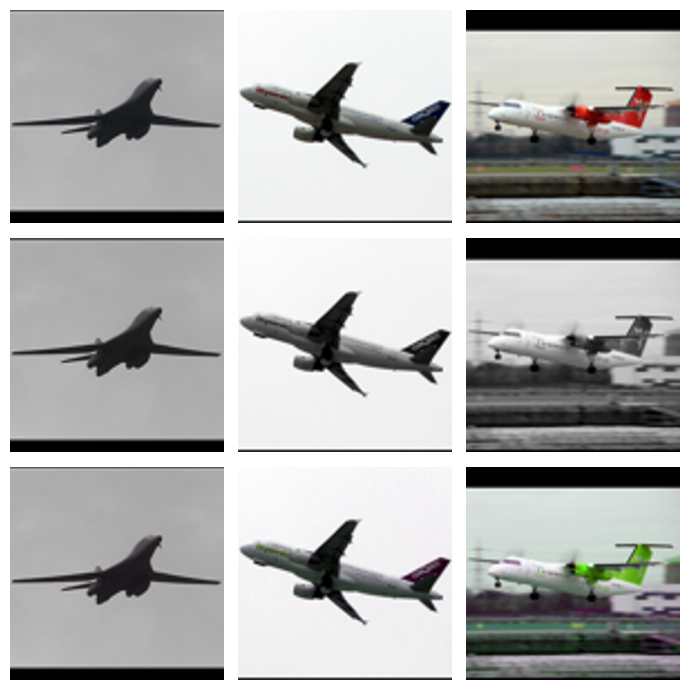

In [ ]:
def grayscale(im):
    return np.asarray(ImageOps.grayscale(Image.fromarray(im)).convert('RGB'),dtype=np.uint8)
def hue_rotate(im):
    hsv=np.asarray(Image.fromarray(im).convert('HSV')).copy()
    hsv[:,:,0]=(hsv[:,:,0].astype(np.uint16)+round(HUE_DEGREES*256/360))%256
    return np.asarray(Image.fromarray(hsv,'HSV').convert('RGB'),dtype=np.uint8)
GRAY=np.stack([grayscale(im) for im in tqdm(X,desc='Grayscale')])
HUE=np.stack([hue_rotate(im) for im in tqdm(X,desc='Hue')])
assert GRAY.shape==HUE.shape==X.shape
fig,ax=plt.subplots(3,3,figsize=(7,7))
for j,img in enumerate([X,GRAY,HUE]):
    for k in range(3): ax[j,k].imshow(img[k]); ax[j,k].axis('off')
for j,label in enumerate(['Clean','Grayscale','Hue +90°']): ax[j,0].set_ylabel(label)
plt.tight_layout(); plt.show()

## 4. Cue conflicts


In [ ]:
from torchvision.models import vgg19, VGG19_Weights

style_net=vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features[:22].to(DEVICE).eval()
for parameter in style_net.parameters(): parameter.requires_grad_(False)
mean=torch.tensor([.485,.456,.406],device=DEVICE).view(1,3,1,1)
std=torch.tensor([.229,.224,.225],device=DEVICE).view(1,3,1,1)

def activations(rgb):
    z=(rgb-mean)/std; found={}
    for i,layer in enumerate(style_net):
        z=layer(z)
        if i in (0,5,10,19,21): found[i]=z.clone()
    return found

def gram(t):
    _,channels,height,width=t.shape
    f=t.reshape(channels,height*width)
    return (f@f.T)/(channels*height*width)

def foreground(image):

    mask=np.zeros((224,224),np.uint8)
    bg=np.zeros((1,65),np.float64); fg=np.zeros((1,65),np.float64)
    cv2.grabCut(image,mask,(12,12,200,200),bg,fg,2,cv2.GC_INIT_WITH_RECT)
    fg_mask=np.where((mask==cv2.GC_FGD)|(mask==cv2.GC_PR_FGD),255,0).astype(np.uint8)
    fg_mask=cv2.morphologyEx(fg_mask,cv2.MORPH_CLOSE,np.ones((3,3),np.uint8))
    return fg_mask

def texture_tile(image):

    crop=Image.fromarray(image[64:160,64:160]).resize((112,112),Image.Resampling.BICUBIC)
    patch=np.asarray(crop)
    return np.concatenate([np.concatenate([patch,patch[:,::-1]],axis=1),
                           np.concatenate([patch[::-1],patch[::-1,::-1]],axis=1)],axis=0)

def stylize(content,style):
    mask=foreground(content)
    m=torch.from_numpy((mask/255).copy()).to(DEVICE,dtype=torch.float32)[None,None]
    foreground_rgb=(content.astype(np.float32)/255)*m.cpu().numpy()[0,0,:, :,None]

    masked=np.clip(foreground_rgb+(1-m.cpu().numpy()[0,0,:,:,None]),0,1)
    c=torch.from_numpy(masked).to(DEVICE).permute(2,0,1)[None].float()
    tiled=texture_tile(style)
    t=torch.from_numpy(np.ascontiguousarray(tiled)).to(DEVICE).permute(2,0,1)[None].float()/255
    with torch.no_grad():
        content_target=activations(c)[21].detach()
        style_targets={i:gram(a).detach() for i,a in activations(t).items() if i!=21}
    pixels=c.detach().clone().requires_grad_(True)
    opt=torch.optim.Adam([pixels],lr=STYLE_LR)
    for _ in range(STYLE_STEPS):
        opt.zero_grad(set_to_none=True)
        z=pixels*m+(1-m)
        out=activations(z)
        content_loss=F.mse_loss(out[21],content_target)
        style_loss=sum(F.mse_loss(gram(out[i]),style_targets[i]) for i in style_targets)
        loss=content_loss+STYLE_WEIGHT*style_loss
        loss.backward();opt.step()
        with torch.no_grad(): pixels.clamp_(0,1)
    final=(pixels.detach()*m+1-m).clamp(0,1)
    rgb=(final[0].permute(1,2,0)*255).round().byte().cpu().numpy()
    del pixels,opt,c,t,final,out
    return rgb,mask,tiled
print('Iterative VGG19 transfer ready; backbones and heads remain unchanged.')


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 177MB/s]


Iterative VGG19 transfer ready; backbones and heads remain unchanged.


In [ ]:
review_file=OUT/'cue_review.csv'; parts=OUT/'cue_parts';parts.mkdir(exist_ok=True)
rng=np.random.default_rng(SEED)
planned=[]
for a,b in PAIRS:
    for source,target in [(a,b),(b,a)]:
        sources=np.flatnonzero(y==CLASSES.index(source))
        donors=np.flatnonzero(y==CLASSES.index(target))
        assert len(sources)>=40 and len(donors)>=2
        for ci in rng.choice(sources,40,replace=False):
            si=int(rng.choice(donors))
            planned.append(dict(candidate_id=len(planned),content_id=int(ci),style_id=si,
                                content_class=source,style_class=target))
assert len(planned)==400
if not review_file.exists(): pd.DataFrame(planned).assign(accept='').to_csv(review_file,index=False)
else:
    prior=pd.read_csv(review_file,keep_default_na=False)
    assert prior.iloc[:400][list(planned[0])].to_dict('records')==planned, 'Existing review CSV has different sampling metadata.'

for k in tqdm(range(10),desc='Transfer directions'):
    part=parts/f'{k:02d}.npz'
    if part.exists(): continue
    batch=[];masks=[]
    for item in tqdm(planned[k*40:(k+1)*40],desc=f'{planned[k*40]["content_class"]} → {planned[k*40]["style_class"]}',leave=False):
        result,mask,_=stylize(X[item['content_id']],X[item['style_id']])
        batch.append(result);masks.append(mask)
    np.savez_compressed(part,images=np.stack(batch),masks=np.stack(masks))
CAND=np.concatenate([np.load(parts/f'{i:02d}.npz')['images'] for i in range(10)])
MASKS=np.concatenate([np.load(parts/f'{i:02d}.npz')['masks'] for i in range(10)])
for addition in sorted(parts.glob('expanded_*.npz'),key=lambda p:int(p.stem.split('_')[1])):
    with np.load(addition) as d:
        CAND=np.concatenate([CAND,d['images']]);MASKS=np.concatenate([MASKS,d['masks']])
assert CAND.shape[1:]==(224,224,3) and MASKS.shape[1:]==(224,224)
review=pd.read_csv(review_file,dtype={'accept':'string'},keep_default_na=False)
assert len(review)==len(CAND) and review.candidate_id.tolist()==list(range(len(CAND)))
print('Candidates:',len(CAND),'| initial 40 per direction | Review:',review_file)


Transfer directions:   0%|          | 0/10 [00:00<?, ?it/s]

airplane → ship:   0%|          | 0/40 [00:00<?, ?it/s]

ship → airplane:   0%|          | 0/40 [00:00<?, ?it/s]

bird → cat:   0%|          | 0/40 [00:00<?, ?it/s]

cat → bird:   0%|          | 0/40 [00:00<?, ?it/s]

...

dog → monkey:   0%|          | 0/40 [00:00<?, ?it/s]

monkey → dog:   0%|          | 0/40 [00:00<?, ?it/s]

car → truck:   0%|          | 0/40 [00:00<?, ?it/s]

truck → car:   0%|          | 0/40 [00:00<?, ?it/s]

Candidates: 400 | initial 40 per direction | Review: /content/drive/MyDrive/ATML_PA1/Task1_STL10_Controlled/cue_review.csv


Saved 40 contact sheets: /content/drive/MyDrive/ATML_PA1/Task1_STL10_Controlled/cue_contact_sheets


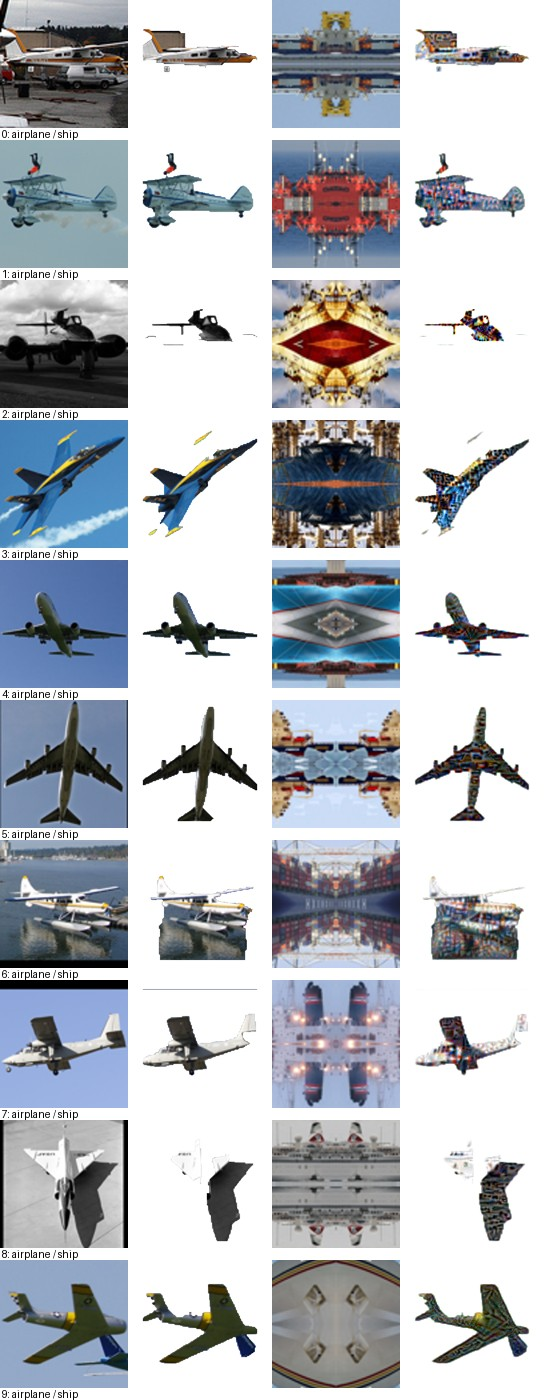

In [ ]:
SHEET=OUT/'cue_contact_sheets';SHEET.mkdir(exist_ok=True)
for start in range(0,len(CAND),10):
    path=SHEET/f'{start:03d}-{min(start+9,len(CAND)-1):03d}.jpg'
    if path.exists(): continue
    canvas=Image.new('RGB',(4*136,10*140),'white'); draw=ImageDraw.Draw(canvas)
    for row,k in enumerate(range(start,min(start+10,len(CAND)))):
        item=review.iloc[k]
        content=X[int(item.content_id)]
        isolated=(content.astype(np.float32)*(MASKS[k,:, :,None]/255)+255*(1-MASKS[k,:, :,None]/255)).round().astype(np.uint8)
        panels=[content,isolated,texture_tile(X[int(item.style_id)]),CAND[k]]
        for j,img in enumerate(panels): canvas.paste(Image.fromarray(img).resize((128,128)),(j*136,row*140))
        draw.text((2,row*140+128),f'{k}: {item.content_class} / {item.style_class}',fill='black')
    canvas.save(path,quality=90)
print('Saved 40 contact sheets:',SHEET)
display(Image.open(SHEET/'000-009.jpg'))


In [ ]:

import ipywidgets as widgets
from IPython.display import clear_output
review=pd.read_csv(review_file,dtype={'accept':'string'},keep_default_na=False)
STRATA=[pair for a,b in PAIRS for pair in [(a,b),(b,a)]]
review_out=widgets.Output()
accept_btn=widgets.Button(description='Accept',button_style='success')
reject_btn=widgets.Button(description='Reject',button_style='danger')

def next_candidate():
    for content_class,style_class in STRATA:
        group=review[(review.content_class==content_class)&(review.style_class==style_class)]
        if (group['accept']=='1').sum()>=20: continue
        remaining=group.index[group['accept']=='']
        if not len(remaining):
            return None,f'Insufficient valid conflicts for {content_class} → {style_class}; run the expansion cell and continue blinded review.'
        return int(remaining[0]),None
    return None,None

def show_next_candidate():
    k,error=next_candidate()
    with review_out:
        clear_output(wait=True)
        if error:
            accept_btn.disabled=reject_btn.disabled=True
            print(error); return
        if k is None:
            accept_btn.disabled=reject_btn.disabled=True
            print('Review complete: 20 accepted in each of 10 directions. Run the validation cell.')
            return
        m=review.iloc[k]
        accepted_count=int((review['accept']=='1').sum())
        rejected_count=int((review['accept']=='0').sum())
        print(f'{accepted_count}/200 accepted · {rejected_count} rejected · candidate {k+1}/{len(CAND)}')
        print(f'Content: {m.content_class} | Style: {m.style_class}')
        canvas=Image.new('RGB',(4*224,224),'white')
        isolated=(X[int(m.content_id)].astype(np.float32)*(MASKS[k,:,:,None]/255)+255*(1-MASKS[k,:,:,None]/255)).round().astype(np.uint8)
        for j,img in enumerate([X[int(m.content_id)],isolated,texture_tile(X[int(m.style_id)]),CAND[k]]):
            canvas.paste(Image.fromarray(img),(j*224,0))
        display(canvas)
        print('Original | Isolated content | Tiled style | Final conflict')

def record_review(value):
    k,error=next_candidate()
    if k is None: return
    review.loc[k,'accept']=value
    review.to_csv(review_file,index=False)
    show_next_candidate()

accept_btn.on_click(lambda _:record_review('1'))
reject_btn.on_click(lambda _:record_review('0'))
display(widgets.HBox([accept_btn,reject_btn]),review_out)
show_next_candidate()

Output()

### More candidates if needed



In [ ]:
review=pd.read_csv(review_file,dtype={'accept':'string'},keep_default_na=False)
assert len(review)==len(CAND)
STRATA=[pair for a,b in PAIRS for pair in [(a,b),(b,a)]]
exhausted=[(a,b) for a,b in STRATA if
    (review.loc[(review.content_class==a)&(review.style_class==b),'accept']=='1').sum()<20 and
    not (review.loc[(review.content_class==a)&(review.style_class==b),'accept']=='').any()]
assert exhausted, 'No exhausted direction: continue visual review.'
rng=np.random.default_rng(SEED+len(CAND))
more=[];more_masks=[];new_rows=[]
for ca,cb in exhausted:
    sources=np.flatnonzero(y==CLASSES.index(ca)); donors=np.flatnonzero(y==CLASSES.index(cb))
    group=review[(review.content_class==ca)&(review.style_class==cb)]
    used=set(zip(group.content_id.astype(int),group.style_id.astype(int)))
    for _ in tqdm(range(40),desc=f'Expand {ca} → {cb}'):
        while True:
            ci=int(rng.choice(sources));si=int(rng.choice(donors))
            if (ci,si) not in used: break
        used.add((ci,si)); image,mask,_=stylize(X[ci],X[si])
        more.append(image);more_masks.append(mask)
        new_rows.append(dict(candidate_id=len(CAND)+len(more)-1,content_id=ci,style_id=si,
                             content_class=ca,style_class=cb,accept=''))
CAND=np.concatenate((CAND,np.stack(more)))
MASKS=np.concatenate((MASKS,np.stack(more_masks)))
review=pd.concat([review,pd.DataFrame(new_rows)],ignore_index=True)

np.savez_compressed(parts/f'expanded_{len(CAND)}.npz',images=np.stack(more),masks=np.stack(more_masks))
review.to_csv(review_file,index=False)
log=OUT/'cue_expansion_log.csv'
pd.concat([pd.read_csv(log),pd.DataFrame(new_rows)] if log.exists() else [pd.DataFrame(new_rows)],ignore_index=True).to_csv(log,index=False)
print('Added',len(more),'candidates. Rerun the reviewer cell.')


Expand truck → car:   0%|          | 0/40 [00:00<?, ?it/s]

Added 40 candidates. Rerun the reviewer cell.


In [ ]:

review=pd.read_csv(review_file,dtype={'accept':'string'},keep_default_na=False)
assert review['candidate_id'].tolist()==list(range(len(CAND)))
assert set(review['accept'])<= {'','0','1'}, 'Only blank, 0, or 1 are valid review decisions.'
counts=review.assign(accept=review['accept'].replace({'':'unreviewed','0':'rejected','1':'accepted'})).groupby(['content_class','style_class','accept']).size().rename('count').reset_index()
display(counts)
accepted_all=review[review['accept']=='1'].copy()
stratum_counts=accepted_all.groupby(['content_class','style_class']).size()
assert len(stratum_counts)==10 and stratum_counts.min()>=20, (
    f'Need >=20 visually valid conflicts in every pair/direction; got {stratum_counts.to_dict()}. '
    'Revise generation and repeat blinded review before evaluating.')

accepted=accepted_all.groupby(['content_class','style_class'],sort=False).head(20).reset_index(drop=True)
assert len(accepted)==200 and accepted.groupby(['content_class','style_class']).size().eq(20).all()
ACCEPTED_CANDIDATE=accepted.candidate_id.to_numpy(dtype=int)
CUE=CAND[ACCEPTED_CANDIDATE]
CUE_CONTENT=accepted.content_id.to_numpy(dtype=int)
CUE_SHAPE=np.array([CLASSES.index(s) for s in accepted.content_class]); CUE_TEXTURE=np.array([CLASSES.index(s) for s in accepted.style_class])
assert np.all(y[CUE_CONTENT]==CUE_SHAPE) and np.all(CUE_SHAPE!=CUE_TEXTURE)
accepted.to_csv(OUT/'cue_accepted_ids.csv',index=False)
counts.to_csv(OUT/'cue_review_counts.csv',index=False)
print(f'Accepted: {len(accepted_all)}; rejected: {(review.accept=='0').sum()}; unreviewed: {(review.accept=='').sum()}; balanced evaluation: {len(accepted)}.')

,content_class,style_class,accept,count
0,airplane,ship,accepted,20
1,airplane,ship,rejected,12
2,airplane,ship,unreviewed,8
3,bird,cat,accepted,20
4,bird,cat,rejected,20
5,car,truck,accepted,20
6,car,truck,rejected,152
7,car,truck,unreviewed,28
8,cat,bird,accepted,20
9,cat,bird,rejected,78


Accepted: 200; rejected: 589; unreviewed: 171; balanced evaluation: 200.


## 5. Translation and patch structure

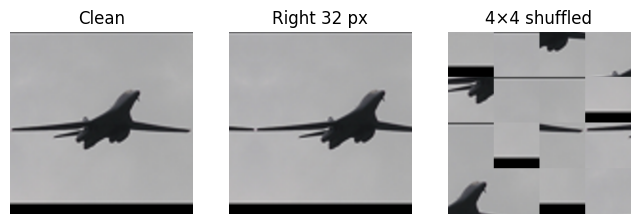

In [ ]:
def translate(im,delta,direction):

    if delta==0: return im.copy()
    p=np.pad(im,((delta,delta),(delta,delta),(0,0)),mode='reflect')
    sy,sx={'right':(delta,0),'left':(delta,2*delta),
           'down':(0,delta),'up':(2*delta,delta)}[direction]
    return np.ascontiguousarray(p[sy:sy+224,sx:sx+224])
DIRECTIONS=['right','left','down','up']
assert np.array_equal(translate(X[0],0,'right'),X[0])
def shuffle_patches(im,permutation):
    patches=im.reshape(4,56,4,56,3).transpose(0,2,1,3,4).reshape(16,56,56,3)
    return np.ascontiguousarray(patches[permutation].reshape(4,4,56,56,3).transpose(0,2,1,3,4).reshape(224,224,3))
rng=np.random.default_rng(SEED); perms=[]
for _ in range(len(X)):
    p=rng.permutation(16)
    while np.array_equal(p,np.arange(16)): p=rng.permutation(16)
    perms.append(p)
perms=np.array(perms)
PATCH=np.stack([shuffle_patches(im,p) for im,p in zip(X,perms)])
assert all(np.array_equal(np.sort(PATCH[i].reshape(-1,3),axis=0),np.sort(X[i].reshape(-1,3),axis=0)) for i in range(2))
np.save(OUT/'patch_permutations.npy',perms)
fig,ax=plt.subplots(1,3,figsize=(8,3))
for a,z,title in zip(ax,[X[0],translate(X[0],32,'right'),PATCH[0]],['Clean','Right 32 px','4×4 shuffled']):
    a.imshow(z); a.set_title(title); a.axis('off')
plt.show()

## 6. Evaluate interventions

In [ ]:

COLOR_FEATURES={}; CUE_FEATURES={}; PATCH_FEATURES={}; TRANS16={}; TRANS_CURVES=[]
def logits_for(m,feat):
    if m=='CLIP zero-shot': return scale*(feat@txt.T)
    w,b=HEADS[m]; return feat@w.T+b

def append_result(m,condition,feat,labels,reference):
    result=summarize(logits_for(m,feat),labels,reference)
    baseline=summarize(CLEAN_LOGITS[m],y)['accuracy']
    ROWS.append(dict(model=m,condition=condition,accuracy_change_pp=100*(result['accuracy']-baseline),**result))

CUE_DECISIONS=[]
for backbone in ['ResNet-50','ViT-B/16','CLIP head']:
    print('Evaluating',backbone)
    model=make_model(backbone)
    fgray=features(model,backbone,GRAY); fhue=features(model,backbone,HUE)
    fcue=features(model,backbone,CUE)
    COLOR_FEATURES[backbone]={'grayscale':fgray,'hue +90°':fhue}
    CUE_FEATURES[backbone]=fcue
    translated_16={}
    for delta in [8,16,32]:
        for direction in DIRECTIONS:
            ims=np.stack([translate(im,delta,direction) for im in X])
            fd=features(model,backbone,ims)
            if delta==16: translated_16[direction]=fd
            for m in ([backbone,'CLIP zero-shot'] if backbone=='CLIP head' else [backbone]):
                z=summarize(logits_for(m,fd),y,PRED_CLEAN[m])
                TRANS_CURVES.append(dict(model=m,pixels=delta,direction=direction,accuracy=z['accuracy'],consistency=z['consistency']))
            del ims,fd
    TRANS16[backbone]=translated_16
    fpatch=features(model,backbone,PATCH)
    PATCH_FEATURES[backbone]=fpatch
    for m in ([backbone,'CLIP zero-shot'] if backbone=='CLIP head' else [backbone]):
        append_result(m,'grayscale',fgray,y,PRED_CLEAN[m])
        append_result(m,'hue +90°',fhue,y,PRED_CLEAN[m])
        append_result(m,'patch shuffle',fpatch,y,PRED_CLEAN[m])
        preds=probs(logits_for(m,fcue)).argmax(1)
        for ix,pred in enumerate(preds):
            CUE_DECISIONS.append(dict(model=m,candidate_id=int(ACCEPTED_CANDIDATE[ix]),
                content_id=int(CUE_CONTENT[ix]),style_id=int(accepted.style_id.iloc[ix]),
                content_label=CLASSES[CUE_SHAPE[ix]],texture_label=CLASSES[CUE_TEXTURE[ix]],
                prediction=CLASSES[pred],decision='shape' if pred==CUE_SHAPE[ix] else 'texture' if pred==CUE_TEXTURE[ix] else 'other'))
    del model
    gc.collect(); torch.cuda.empty_cache()
print('Evaluation complete.')

Evaluating ResNet-50
Evaluating ViT-B/16
Evaluating CLIP head


/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Evaluation complete.


### Clean, color, and patch results

In [ ]:
performance=pd.DataFrame(ROWS)
performance['accuracy_change_pp']=performance['accuracy_change_pp'].fillna(0)
performance.to_csv(OUT/'performance.csv',index=False)
show_table(performance[['model','condition','accuracy','accuracy_change_pp','macro_f1','mean_max_confidence','consistency']].round(4))
print('Accuracy change is in percentage points; consistency compares predictions with the same clean image.')

,model,condition,accuracy,accuracy_change_pp,macro_f1,mean_max_confidence,consistency
0,ResNet-50,clean,0.974,0.0,0.9741,0.9091,NaN
1,ViT-B/16,clean,0.974,0.0,0.9739,0.9694,NaN
2,CLIP head,clean,0.976,0.0,0.9760,0.1391,NaN
3,CLIP zero-shot,clean,0.968,0.0,0.9675,0.9427,NaN
4,ResNet-50,grayscale,0.956,-1.8,0.9559,0.9126,0.962
5,ResNet-50,hue +90°,0.930,-4.4,0.9298,0.8941,0.940
6,ResNet-50,patch shuffle,0.882,-9.2,0.8827,0.8773,0.898
7,ViT-B/16,grayscale,0.952,-2.2,0.9520,0.9654,0.952
8,ViT-B/16,hue +90°,0.940,-3.4,0.9399,0.9419,0.944
9,ViT-B/16,patch shuffle,0.894,-8.0,0.8927,0.9093,0.898


Accuracy change is in percentage points; consistency compares predictions with the same clean image.


### Shape versus texture

,model,shape,texture,other,total,shape_bias_pct,coverage_pct
0,ResNet-50,76,30,94,200,71.70,53.0
1,ViT-B/16,90,27,83,200,76.92,58.5
2,CLIP head,94,30,76,200,75.81,62.0
3,CLIP zero-shot,112,40,48,200,73.68,76.0


decision                                    other  shape  texture
model          content_label texture_label                       
CLIP head      airplane      ship               7     12        1
               bird          cat                1     15        4
               car           truck              4      8        8
               cat           bird               4     11        5
               deer          horse              6     14        0
               dog           monkey             7     12        1
               horse         deer              14      3        3
               monkey        dog               10      4        6
               ship          airplane          17      2        1
               truck         car                6     13        1
CLIP zero-shot airplane      ship               3     10        7
               bird          cat                2     18        0
               car           truck              2     13        5
               cat           bird               4     10        6
               deer          horse              2      6       12
               dog           monkey             7     12        1
               horse         deer               7     11        2
               monkey        dog               11      6        3
               ship          airplane           9     11        0
               truck         car                1     15        4
ResNet-50      airplane      ship               6     11        3
               bird          cat                0     17        3
               car           truck              6      3       11
               cat           bird               0     13        7
               deer          horse             17      2        1
               dog           monkey            15      5        0
               horse         deer              17      1        2
               monkey        dog               18      1        1
               ship          airplane          10      9        1
               truck         car                5     14        1
ViT-B/16       airplane      ship               6     11        3
               bird          cat                0     19        1
               car           truck              7     11        2
               cat           bird               5      7        8
               deer          horse             14      2        4
               dog           monkey             7     13        0
               horse         deer              12      6        2
               monkey        dog               15      4        1
               ship          airplane          11      8        1
               truck         car                6      9        5

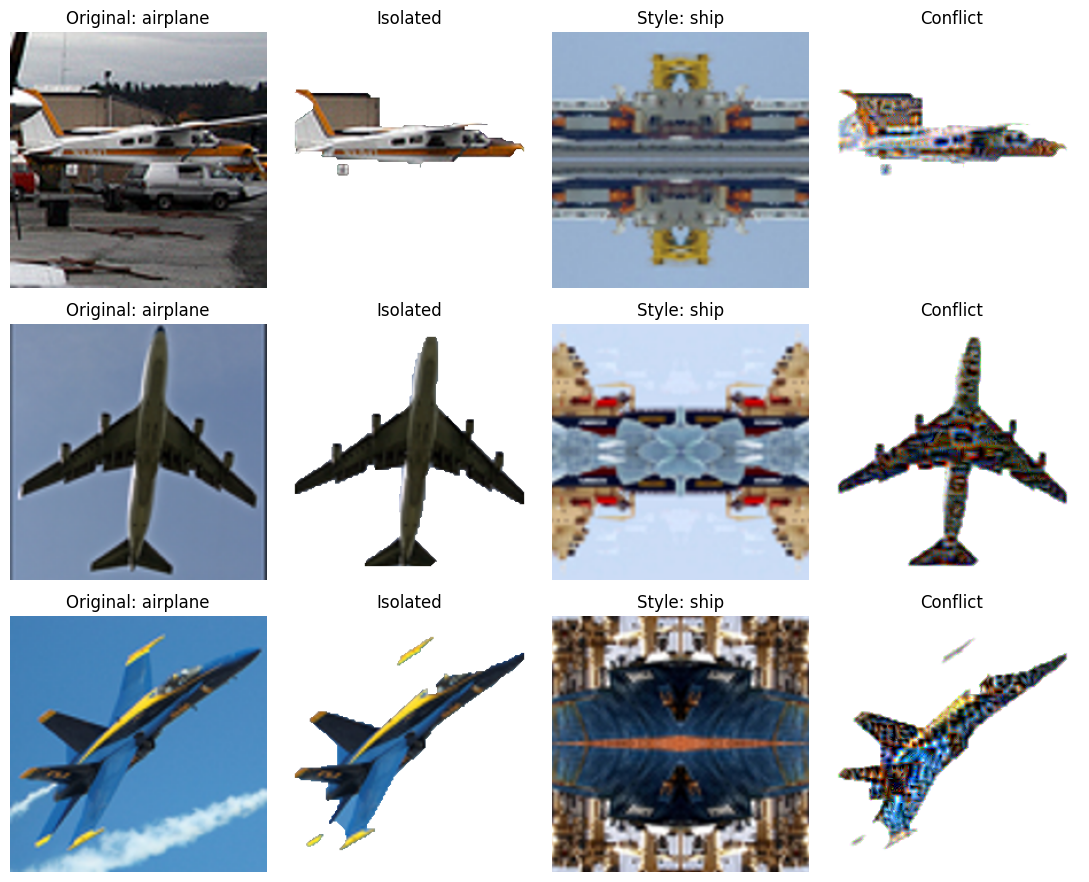

In [ ]:
cue_df=pd.DataFrame(CUE_DECISIONS); cue_df.to_csv(OUT/'cue_predictions.csv',index=False)
shape_rows=[]
for m,g in cue_df.groupby('model',sort=False):
    z=g.decision.value_counts(); ns=int(z.get('shape',0)); nt=int(z.get('texture',0)); no=int(z.get('other',0))
    shape_rows.append(dict(model=m,shape=ns,texture=nt,other=no,total=len(g),
        shape_bias_pct=100*ns/(ns+nt) if ns+nt else np.nan,coverage_pct=100*(ns+nt)/len(g)))
shape_table=pd.DataFrame(shape_rows);shape_table.to_csv(OUT/'shape_bias.csv',index=False)
show_table(shape_table.round(2))
assert (shape_table[['shape','texture','other']].sum(axis=1)==shape_table.total).all()
show_table(cue_df.groupby(['model','content_label','texture_label','decision']).size().rename('n').unstack(fill_value=0))

piv=cue_df.pivot(index='candidate_id',columns='model',values='decision')
examples=[]
for title,condition in [('shape agreement',(piv=='shape').all(axis=1)),
                         ('mixed decisions',piv.nunique(axis=1)>1),('other-label failure',(piv=='other').any(axis=1))]:
    hits=piv.index[condition]
    if len(hits): examples.append((title,int(hits[0])))
if not examples:
    examples=[('first reviewed conflict',int(piv.index[0]))]
fig,axes=plt.subplots(len(examples),4,figsize=(11,3*len(examples)),squeeze=False)
for row,(title,cid) in enumerate(examples):
    r=review.iloc[cid]
    for col,(im,label) in enumerate([(X[int(r.content_id)],'Original: '+r.content_class),
                                      ((X[int(r.content_id)].astype(np.float32)*(MASKS[cid,:,:,None]/255)+255*(1-MASKS[cid,:,:,None]/255)).astype(np.uint8),'Isolated'),
                                      (texture_tile(X[int(r.style_id)]),'Style: '+r.style_class),(CAND[cid],'Conflict')]):
        axes[row,col].imshow(im); axes[row,col].set_title(label); axes[row,col].axis('off')
    predictions=cue_df[cue_df.candidate_id==cid].set_index('model')['prediction'].to_dict()
    axes[row,3].set_xlabel(f'{title} · id {cid} | {predictions}',fontsize=8)
plt.tight_layout();plt.savefig(OUT/'cue_examples.png',dpi=160,bbox_inches='tight');plt.show()

### Translation

,model,pixels,accuracy,consistency
0,CLIP head,0,0.9760,1.0000
1,CLIP head,8,0.9795,0.9875
2,CLIP head,16,0.9750,0.9820
3,CLIP head,32,0.9680,0.9810
4,CLIP zero-shot,0,0.9680,1.0000
5,CLIP zero-shot,8,0.9690,0.9810
6,CLIP zero-shot,16,0.9725,0.9795
7,CLIP zero-shot,32,0.9560,0.9730
8,ResNet-50,0,0.9740,1.0000
9,ResNet-50,8,0.9730,0.9930


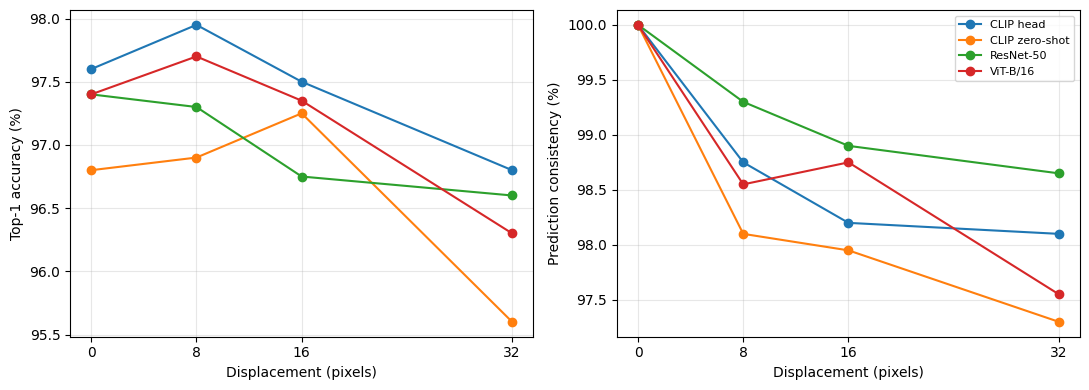

In [ ]:
curves=pd.DataFrame(TRANS_CURVES)
for m in NAMES:
    baseline=summarize(CLEAN_LOGITS[m],y)
    curves.loc[len(curves)]=dict(model=m,pixels=0,direction='all',accuracy=baseline['accuracy'],consistency=1.0)
curves.to_csv(OUT/'translation_by_direction.csv',index=False)
mean_curve=curves.groupby(['model','pixels'],as_index=False)[['accuracy','consistency']].mean()
mean_curve.to_csv(OUT/'translation_mean.csv',index=False)
show_table(mean_curve.round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for m,g in mean_curve.groupby('model'):
    g=g.sort_values('pixels')
    for a,metric in zip(axes,['accuracy','consistency']): a.plot(g.pixels,100*g[metric],marker='o',label=m)
for a,title in zip(axes,['Top-1 accuracy','Prediction consistency']):
    a.set(xlabel='Displacement (pixels)',ylabel=title+' (%)',xticks=[0,8,16,32]);a.grid(alpha=.3)
axes[1].legend(fontsize=8);plt.tight_layout();plt.savefig(OUT/'translation.png',dpi=160);plt.show()

## 7. Representation analysis

In [ ]:
def cosine_mean(a,b):
    a=F.normalize(torch.from_numpy(a).float(),dim=1)
    b=F.normalize(torch.from_numpy(b).float(),dim=1)
    return (a*b).sum(1).mean().item()
STABILITY=[]
for m in ['ResNet-50','ViT-B/16','CLIP head']:
    fc=CLEAN_FEATURES[m]
    for name,z in [('grayscale',COLOR_FEATURES[m]['grayscale']),('cue conflict',CUE_FEATURES[m]),
                   ('patch shuffle',PATCH_FEATURES[m])]:
        base=fc[CUE_CONTENT] if name=='cue conflict' else fc
        STABILITY.append(dict(backbone=m,intervention=name,n=len(z),mean_cosine=cosine_mean(base,z)))
    for d,z in TRANS16[m].items():
        STABILITY.append(dict(backbone=m,intervention=f'translation 16 px {d}',n=len(z),mean_cosine=cosine_mean(fc,z)))
    STABILITY.append(dict(backbone=m,intervention='translation 16 px, four-direction mean',n=4*len(fc),
                          mean_cosine=np.mean([cosine_mean(fc,z) for z in TRANS16[m].values()])))
stability=pd.DataFrame(STABILITY);stability.to_csv(OUT/'representation_stability.csv',index=False)
show_table(stability.round(4))

,backbone,intervention,n,mean_cosine
0,ResNet-50,grayscale,500,0.7885
1,ResNet-50,cue conflict,200,0.2613
2,ResNet-50,patch shuffle,500,0.7150
3,ResNet-50,translation 16 px right,500,0.9440
4,ResNet-50,translation 16 px left,500,0.9608
5,ResNet-50,translation 16 px down,500,0.9493
6,ResNet-50,translation 16 px up,500,0.9559
7,ResNet-50,"translation 16 px, four-direction mean",2000,0.9525
8,ViT-B/16,grayscale,500,0.7393
9,ViT-B/16,cue conflict,200,0.1457


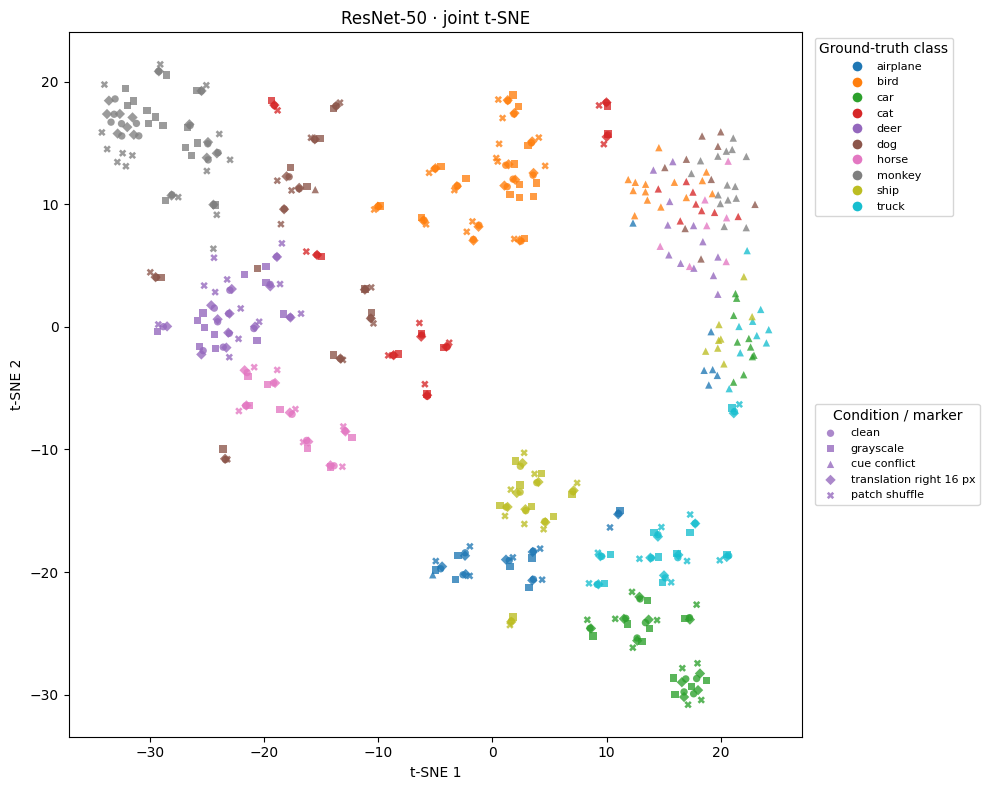

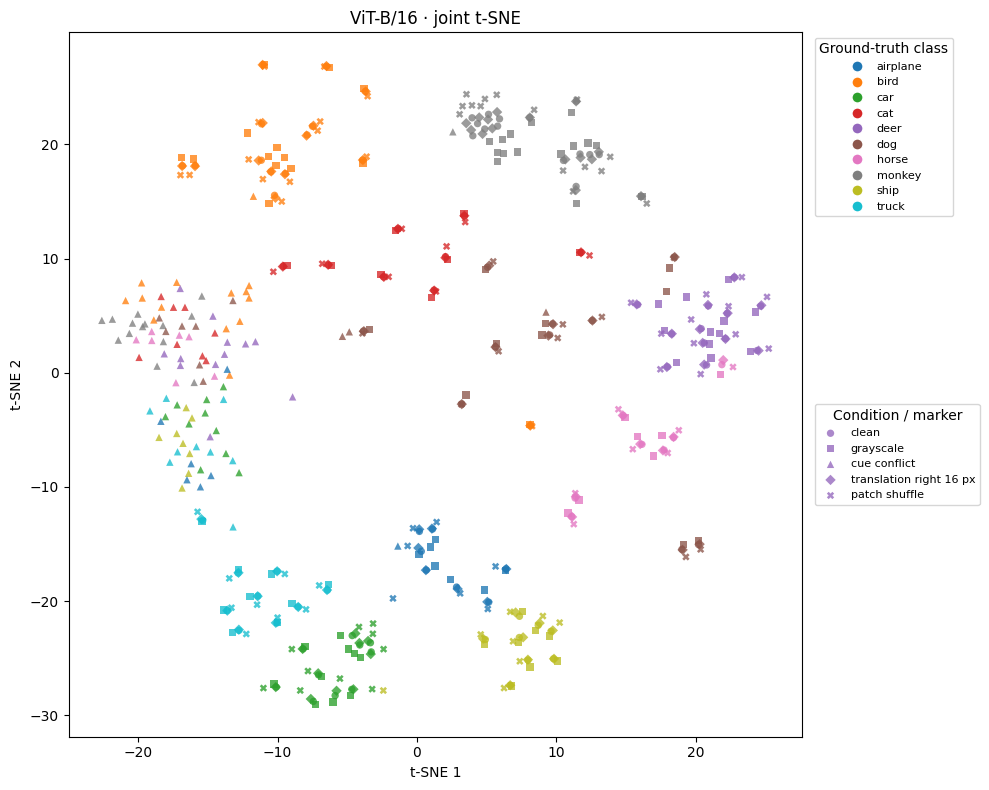

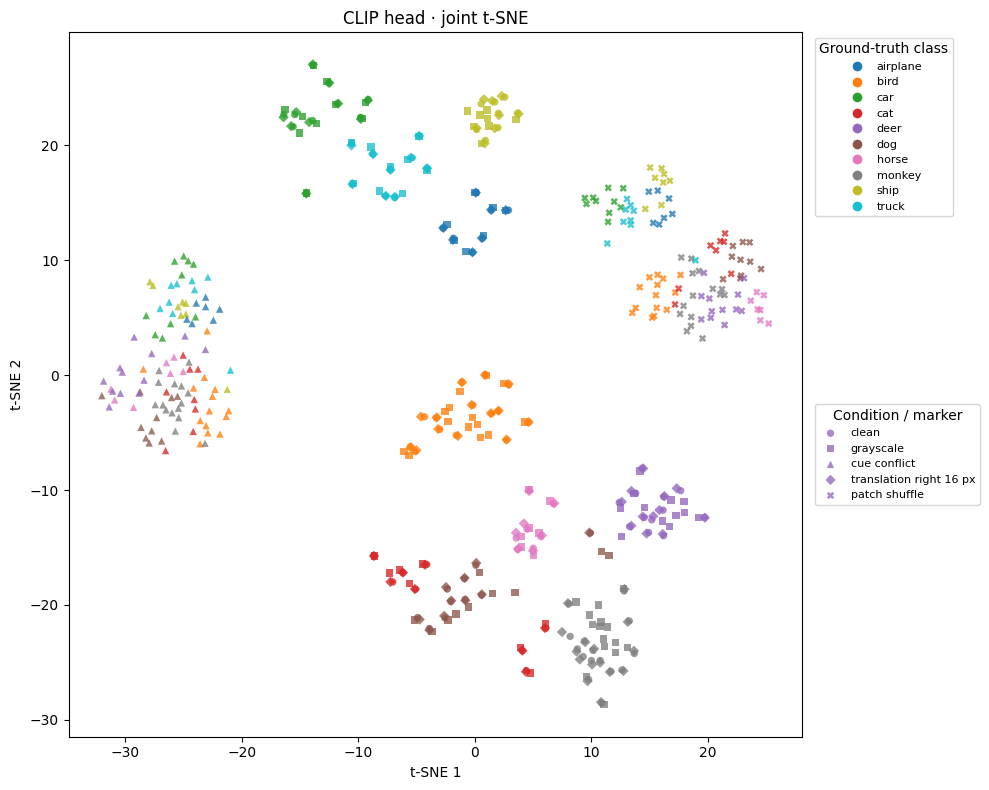

Settings: t-SNE, cosine metric, normalized input vectors, perplexity 30, PCA init, learning rate auto, seed 6304; 100 exact matched images per condition. Projection coordinates across backbones are not comparable.


In [ ]:
rng = np.random.default_rng(SEED)
vis_rows = []
seen = set()

for row in rng.permutation(len(accepted)):
    content_id = int(CUE_CONTENT[row])
    if content_id not in seen:
        seen.add(content_id)
        vis_rows.append(int(row))
    if len(vis_rows) == VIS_N:
        break

assert len(vis_rows) == VIS_N, (
    f'Only {len(vis_rows)} distinct accepted content images; need {VIS_N}.'
)
vis_rows = np.asarray(vis_rows, dtype=int)
vis_ids = CUE_CONTENT[vis_rows]
vis_labels = y[vis_ids]

np.savez(
    OUT/'visualization_ids.npz',
    content_id=vis_ids,
    candidate_id=ACCEPTED_CANDIDATE[vis_rows],
    labels=vis_labels
)
for m in ['ResNet-50','ViT-B/16','CLIP head']:
    conditions={'clean':CLEAN_FEATURES[m][vis_ids],
                'grayscale':COLOR_FEATURES[m]['grayscale'][vis_ids],
                'cue conflict':CUE_FEATURES[m][vis_rows],
                'translation right 16 px':TRANS16[m]['right'][vis_ids],
                'patch shuffle':PATCH_FEATURES[m][vis_ids]}
    Z=np.concatenate(list(conditions.values())).astype(np.float32)
    Z=F.normalize(torch.from_numpy(Z),dim=1).numpy()
    emb=TSNE(n_components=2,perplexity=30,metric='cosine',init='pca',learning_rate='auto',
             random_state=SEED).fit_transform(Z)
    fig,ax=plt.subplots(figsize=(10,8)); markers=['o','s','^','D','X'];
    cmap=plt.get_cmap('tab10')
    for ci,(condition,marker) in enumerate(zip(conditions,markers)):
        points=emb[ci*VIS_N:(ci+1)*VIS_N]
        ax.scatter(points[:,0],points[:,1],c=[cmap(int(v)) for v in vis_labels],
                   s=28,marker=marker,alpha=.78,label=condition,edgecolors='none')
    handles=[plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=cmap(i),markersize=8,label=label) for i,label in enumerate(CLASSES)]
    leg=ax.legend(handles=handles,title='Ground-truth class',bbox_to_anchor=(1.01,1),loc='upper left',fontsize=8)
    ax.add_artist(leg);ax.legend(title='Condition / marker',bbox_to_anchor=(1.01,.48),loc='upper left',fontsize=8)
    ax.set(title=f'{m} · joint t-SNE',xlabel='t-SNE 1',ylabel='t-SNE 2')
    plt.tight_layout();plt.savefig(OUT/(m.replace('/','_').replace(' ','_')+'_tsne.png'),dpi=170,bbox_inches='tight');plt.show()
    pd.DataFrame({'x':emb[:,0],'y':emb[:,1],'condition':np.repeat(list(conditions),VIS_N),
                  'content_id':np.tile(vis_ids,len(conditions)),'class_id':np.tile(vis_labels,len(conditions))}).to_csv(
                      OUT/(m.replace('/','_').replace(' ','_')+'_tsne.csv'),index=False)
print('Settings: t-SNE, cosine metric, normalized input vectors, perplexity 30, PCA init, learning rate auto, seed 6304; 100 exact matched images per condition. Projection coordinates across backbones are not comparable.')